#**Used Car Price Prediction**

1) Problem statement.

This dataset comprises used cars sold on cardehko.com in India as well as important features of these cars.

If user can predict the price of the car based on input features.

Prediction results can be used to give new seller the price suggestion based on market condition.

2) Data Collection.

The Dataset is collected from scrapping from cardheko webiste

The data consists of 13 column and 15411 rows.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [13]:
import kagglehub
path = kagglehub.dataset_download("manishkr1754/cardekho-used-car-data")

Using Colab cache for faster access to the 'cardekho-used-car-data' dataset.


In [14]:
path

'/kaggle/input/cardekho-used-car-data'

In [15]:
import os
os.listdir(path)

['cardekho_dataset.csv']

In [16]:
df = pd.read_csv('/kaggle/input/cardekho-used-car-data/cardekho_dataset.csv')

**EDA**

In [17]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [18]:
df.drop(columns="Unnamed: 0", inplace=True)

since we can identify the car by model name so instead of having three columns we only keep one

In [19]:
df.drop(columns=["car_name","brand"], inplace = True)

In [20]:
df.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [21]:
df.isnull().sum()

,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,0
engine,0
max_power,0
seats,0


In [22]:
df['model'].unique()

array(['Alto', 'Grand', 'i20', 'Ecosport', 'Wagon R', 'i10', 'Venue',
       'Swift', 'Verna', 'Duster', 'Cooper', 'Ciaz', 'C-Class', 'Innova',
       'Baleno', 'Swift Dzire', 'Vento', 'Creta', 'City', 'Bolero',
       'Fortuner', 'KWID', 'Amaze', 'Santro', 'XUV500', 'KUV100', 'Ignis',
       'RediGO', 'Scorpio', 'Marazzo', 'Aspire', 'Figo', 'Vitara',
       'Tiago', 'Polo', 'Seltos', 'Celerio', 'GO', '5', 'CR-V',
       'Endeavour', 'KUV', 'Jazz', '3', 'A4', 'Tigor', 'Ertiga', 'Safari',
       'Thar', 'Hexa', 'Rover', 'Eeco', 'A6', 'E-Class', 'Q7', 'Z4', '6',
       'XF', 'X5', 'Hector', 'Civic', 'D-Max', 'Cayenne', 'X1', 'Rapid',
       'Freestyle', 'Superb', 'Nexon', 'XUV300', 'Dzire VXI', 'S90',
       'WR-V', 'XL6', 'Triber', 'ES', 'Wrangler', 'Camry', 'Elantra',
       'Yaris', 'GL-Class', '7', 'S-Presso', 'Dzire LXI', 'Aura', 'XC',
       'Ghibli', 'Continental', 'CR', 'Kicks', 'S-Class', 'Tucson',
       'Harrier', 'X3', 'Octavia', 'Compass', 'CLS', 'redi-GO', 'Glanza',
       

In [23]:
num_features = df.select_dtypes(exclude="object").columns
print("Numerical Features=", len(num_features))
cat_features = df.select_dtypes(include="object").columns
print("Categorical Features=", len(cat_features))
discrete_features = [feature for feature in num_features if len(df[feature].unique())<25]
print("Discrete Features=", len(discrete_features))
continous_features = [feature for feature in num_features if feature not in discrete_features]
print("Continous Features=",len(continous_features))

Numerical Features= 7
Categorical Features= 4
Discrete Features= 2
Continous Features= 5


In [24]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

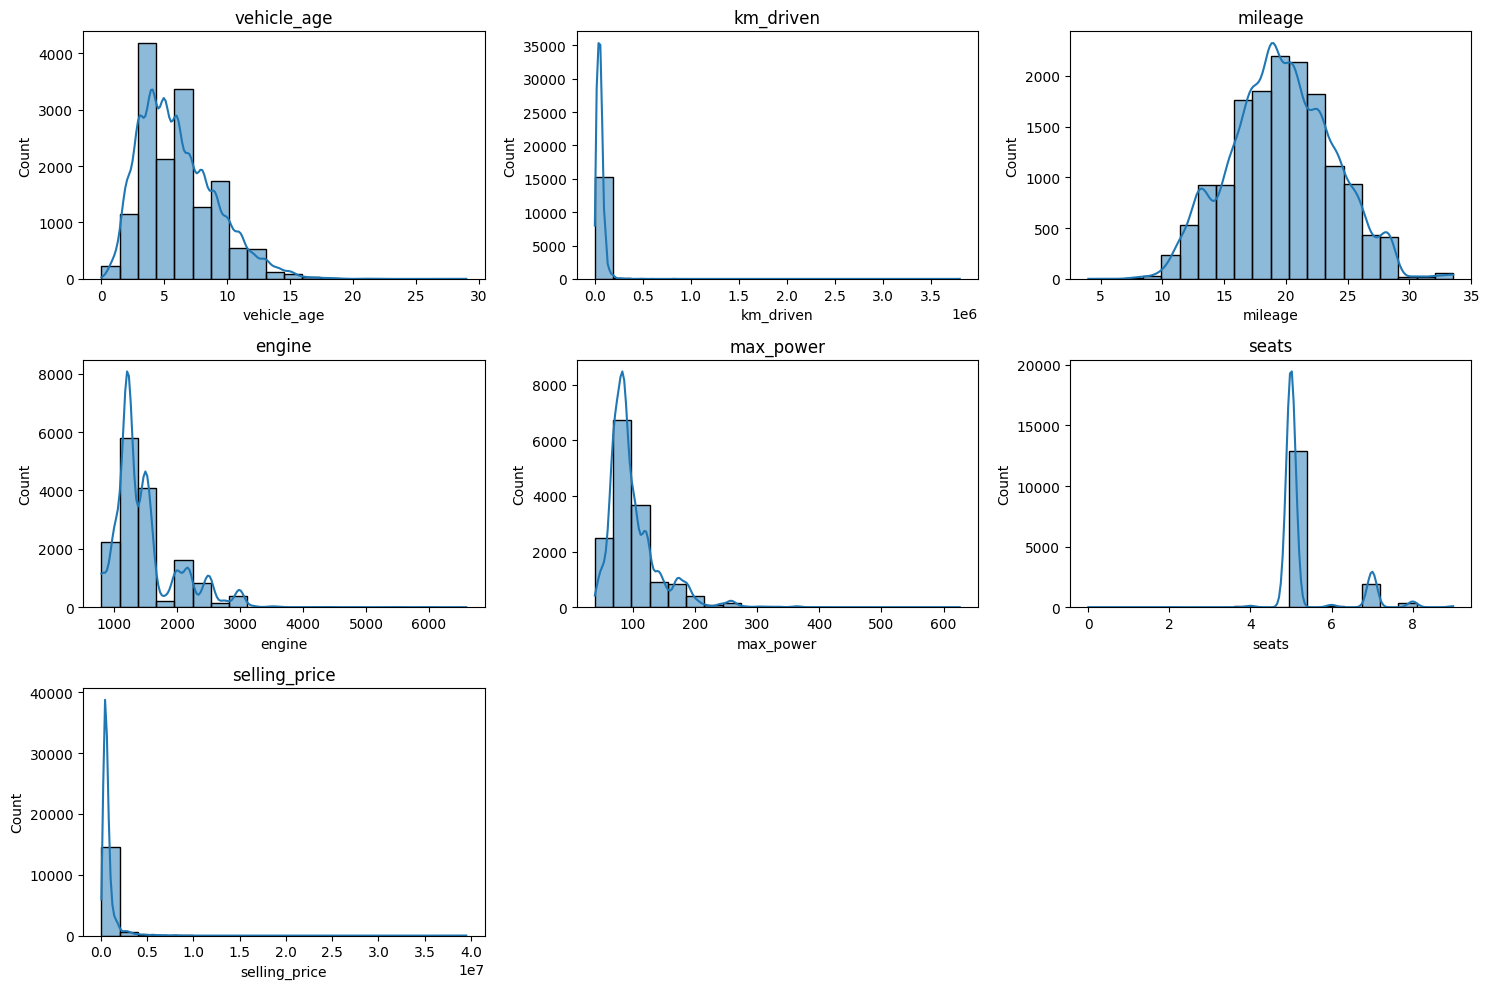

In [25]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols)//3 + 1, 3, i)
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

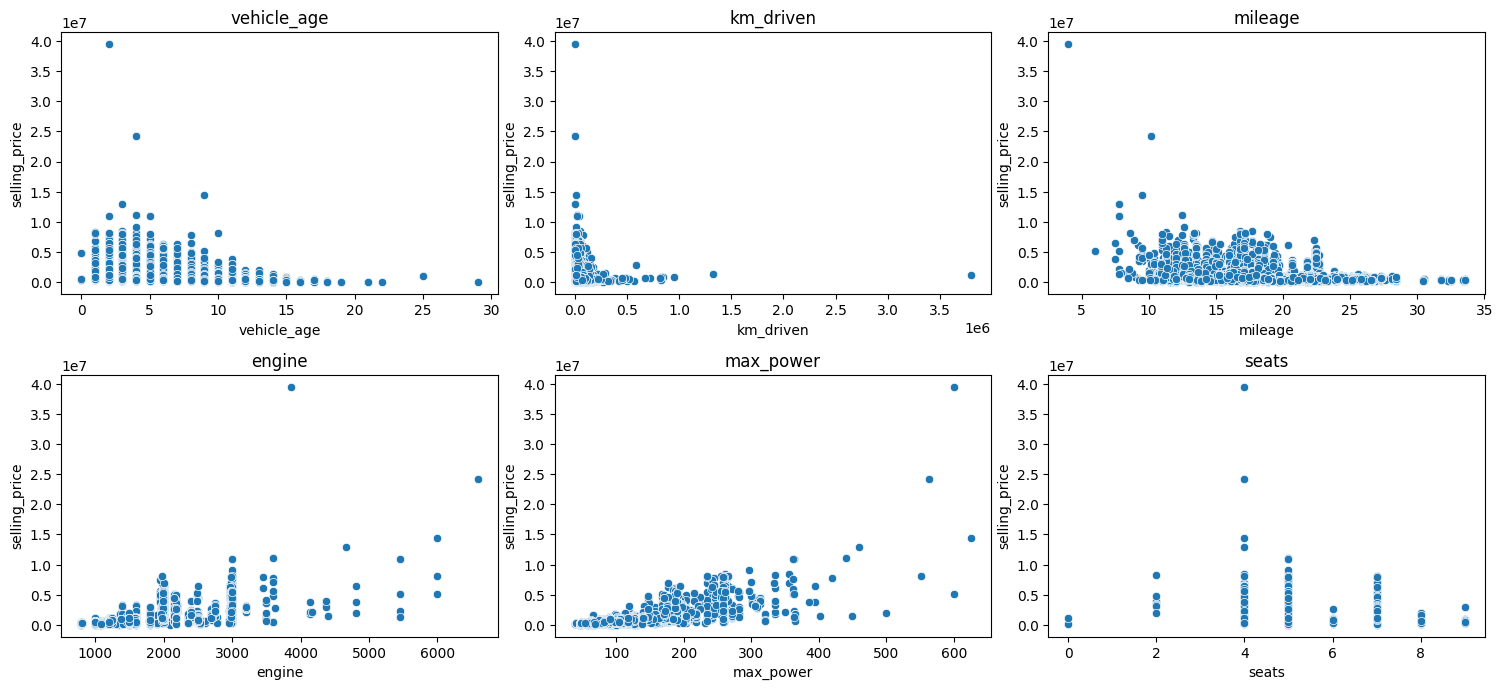

In [26]:
plt.figure(figsize=(15, 10))

i = 1
for col in num_cols:
    if col != 'selling_price':
        plt.subplot(len(num_cols)//3 + 1, 3, i)
        sns.scatterplot(x=df[col], y=df['selling_price'])
        plt.title(col)
        i += 1

plt.tight_layout()
plt.show()

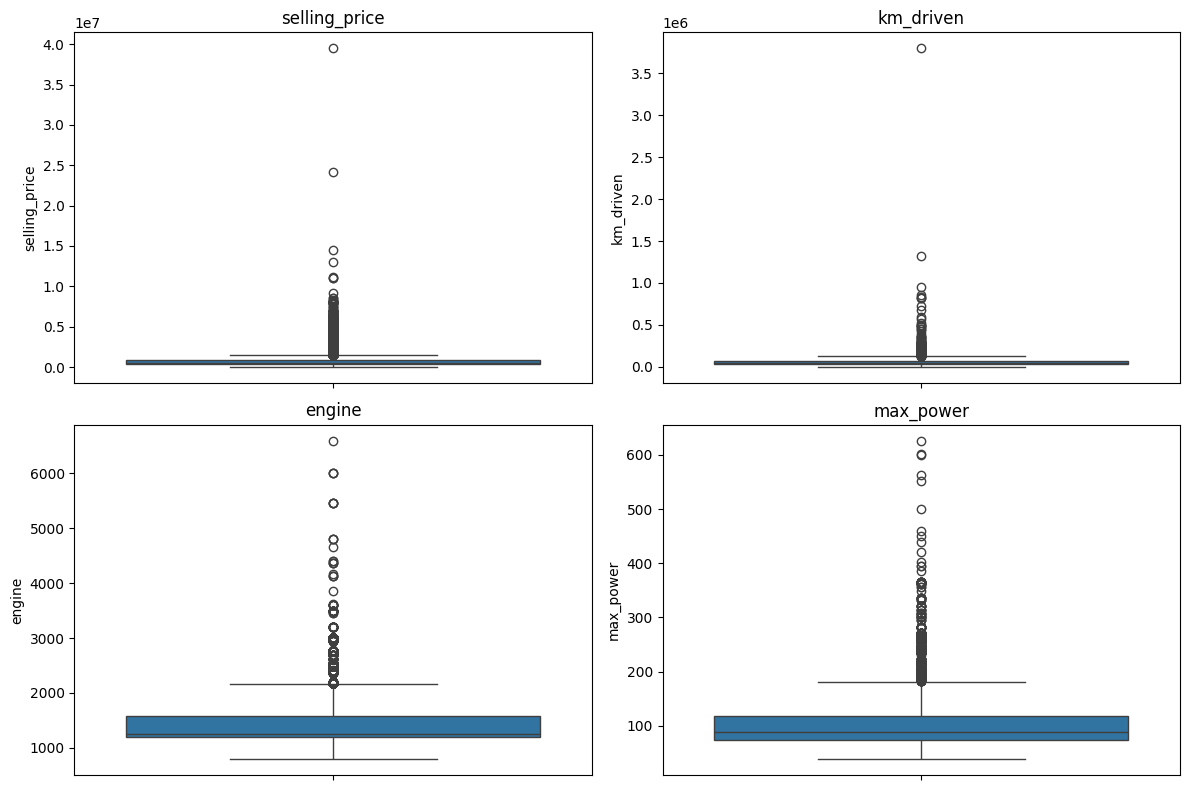

In [27]:
cols = ['selling_price', 'km_driven', 'engine', 'max_power']

plt.figure(figsize=(12,8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [28]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[col] >= lower) & (df[col] <= upper)]

cols = ['selling_price', 'km_driven', 'engine', 'max_power']

for col in cols:
    df = remove_outliers(df, col)


In [29]:
for col in cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)


In [30]:
import numpy as np

df['selling_price'] = np.log1p(df['selling_price'])
df['km_driven'] = np.log1p(df['km_driven'])


In [31]:
from sklearn.model_selection import train_test_split
X= df.drop(columns='selling_price')
y= df['selling_price']

In [32]:
X.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,Alto,9,11.695255,Individual,Petrol,Manual,19.70,796,46.30,5
1,Grand,5,9.903538,Individual,Petrol,Manual,18.90,1197,82.00,5
2,i20,11,11.002117,Individual,Petrol,Manual,17.00,1197,80.00,5
3,Alto,9,10.518700,Individual,Petrol,Manual,20.92,998,67.10,5
4,Ecosport,6,10.308986,Dealer,Diesel,Manual,22.77,1498,98.59,5


**Feature Encoding and Scaling**

In [33]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X['model'] = le.fit_transform(X['model'])


In [34]:
X.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,0,9,11.695255,Individual,Petrol,Manual,19.70,796,46.30,5
1,24,5,9.903538,Individual,Petrol,Manual,18.90,1197,82.00,5
2,55,11,11.002117,Individual,Petrol,Manual,17.00,1197,80.00,5
3,0,9,10.518700,Individual,Petrol,Manual,20.92,998,67.10,5
4,16,6,10.308986,Dealer,Diesel,Manual,22.77,1498,98.59,5


In [35]:
len(df['seller_type'].unique()),len(df['fuel_type'].unique()),len(df['transmission_type'].unique())

(3, 4, 2)

In [36]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11928 entries, 0 to 15410
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   model              11928 non-null  int64  
 1   vehicle_age        11928 non-null  int64  
 2   km_driven          11928 non-null  float64
 3   seller_type        11928 non-null  object 
 4   fuel_type          11928 non-null  object 
 5   transmission_type  11928 non-null  object 
 6   mileage            11928 non-null  float64
 7   engine             11928 non-null  int64  
 8   max_power          11928 non-null  float64
 9   seats              11928 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 1.0+ MB


In [37]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer


numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop='first')

num_features = [col for col in X.select_dtypes(exclude='object').columns if col != 'model']
onehot_columns = ['seller_type', 'fuel_type', 'transmission_type']

preprocessor = ColumnTransformer(
    [
        ('OneHotEncoder', oh_transformer, onehot_columns),
        ('StandardScaler', numeric_transformer, num_features)

    ],remainder='passthrough'
)


In [38]:
X.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,0,9,11.695255,Individual,Petrol,Manual,19.70,796,46.30,5
1,24,5,9.903538,Individual,Petrol,Manual,18.90,1197,82.00,5
2,55,11,11.002117,Individual,Petrol,Manual,17.00,1197,80.00,5
3,0,9,10.518700,Individual,Petrol,Manual,20.92,998,67.10,5
4,16,6,10.308986,Dealer,Diesel,Manual,22.77,1498,98.59,5


In [39]:
X=preprocessor.fit_transform(X)

In [40]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.0,0.0,0.0,0.0,1.0,1.0,1.055267,1.530912,-0.385150,-2.192998,-2.031012,-0.208750,0.0
1,1.0,0.0,0.0,0.0,1.0,1.0,-0.288768,-0.966003,-0.616955,-0.269052,-0.149076,-0.208750,24.0
2,1.0,0.0,0.0,0.0,1.0,1.0,1.727285,0.564962,-1.167491,-0.269052,-0.254507,-0.208750,55.0
3,1.0,0.0,0.0,0.0,1.0,1.0,1.055267,-0.108720,-0.031648,-1.223828,-0.934534,-0.208750,0.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.047241,-0.400975,0.504401,1.175107,0.725471,-0.208750,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11923,0.0,0.0,0.0,0.0,1.0,1.0,-0.288768,-2.043696,-0.616955,-0.269052,-0.149076,-0.208750,24.0
11924,0.0,0.0,0.0,0.0,1.0,1.0,1.055267,-1.834623,-0.353277,-0.801616,-0.884455,-0.208750,54.0
11925,0.0,0.0,0.0,0.0,1.0,1.0,-1.296795,-1.112824,-1.022613,0.575373,0.330633,4.626135,19.0
11926,0.0,0.0,1.0,0.0,0.0,1.0,0.047241,0.718740,0.032099,1.175107,0.985357,-0.208750,35.0


In [41]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [42]:
X_train.shape

(9542, 13)

In [43]:
y_train.shape

(9542,)

**Model Training**

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [45]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [46]:
#lets begin model training
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),

}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    #make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)


    #evaluate train and test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 0.2073
- Mean Absolute Error: 0.1638
- R2 Score: 0.8132
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.2098
- Mean Absolute Error: 0.1648
- R2 Score: 0.8138


Ridge
Model performance for Training set
- Root Mean Squared Error: 0.2073
- Mean Absolute Error: 0.1638
- R2 Score: 0.8132
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.2098
- Mean Absolute Error: 0.1648
- R2 Score: 0.8138


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 0.1338
- Mean Absolute Error: 0.1000
- R2 Score: 0.9221
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.1613
- Mean Absolute Error: 0.1216
- R2 Score: 0.8899


Decision Tree
Model performance for Training set
- Root Mean Squared Error: 0.0402
- Mean Absolute Error: 0.0116
- R2 Score: 0.9930
---------------

In [47]:
#choosing only the models which performed best
rf_params = {"max_depth": [5,8,15,None,10],
             "max_features": [5,7,"auto",8],
             "min_samples_split": [2,8,15,20],
             "n_estimators":[50,60,70,80]}

gb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_samples_split': [2, 5, 10]
}


In [48]:
randomcv_models = [
    ("Random Forest", RandomForestRegressor(), rf_params),
    ("Gradient Boosting", GradientBoostingRegressor(), gb_params)
]

In [49]:
from warnings import filterwarnings
filterwarnings('ignore')

In [50]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, param in randomcv_models:
  random = RandomizedSearchCV(
      estimator=model,
      param_distributions=param,
      n_iter=100,
      cv=3,
      verbose=2,
      n_jobs=-1)


  random.fit(X_train, y_train)
  model_param[name] = random.best_params_

for model_name in model_param:
  print(f"-----------Best Params for {model_name}-----------")
  print(model_param[model_name])
  print("="*35)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 81 candidates, totalling 243 fits
-----------Best Params for Random Forest-----------
{'n_estimators': 80, 'min_samples_split': 15, 'max_features': 7, 'max_depth': None}
-----------Best Params for Gradient Boosting-----------
{'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 5, 'learning_rate': 0.05}


In [54]:
#lets begin model training
models = {
    "Random Forest Regressor": RandomForestRegressor(n_estimators=80, min_samples_split=15, max_features=7, max_depth=None),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, min_samples_split=10, max_depth=5, learning_rate=0.05)

}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    #make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)


    #evaluate train and test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    print('='*35)
    print('\n')

Random Forest Regressor
Model performance for Training set
- Root Mean Squared Error: 0.1202
- Mean Absolute Error: 0.0917
- R2 Score: 0.9372
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.1480
- Mean Absolute Error: 0.1129
- R2 Score: 0.9073


Gradient Boosting
Model performance for Training set
- Root Mean Squared Error: 0.1323
- Mean Absolute Error: 0.1016
- R2 Score: 0.9239
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.1472
- Mean Absolute Error: 0.1126
- R2 Score: 0.9083




In [55]:
gb_model = GradientBoostingRegressor(n_estimators=300, min_samples_split=10, max_depth=5, learning_rate=0.05)
gb_model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, min_samples_split=10,
                          n_estimators=300)

In [56]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", gb_model)
])


In [57]:
import joblib
joblib.dump(pipeline, "final_pipeline.pkl")


['final_pipeline.pkl']